# 03 - Model Interpretation (SHAP)
### Capstone Project: Deteksi SMS Spam
**Nama:** Vasya Citra Narindra &nbsp;|&nbsp; **NIM:** A11.2024.15987 &nbsp;|&nbsp; **Kelompok:** A11.4404

Notebook ini melanjutkan **Soal 3 (Modeling & Evaluation)** — khusus bagian *"Analisis feature
importance/model interpretasi (SHAP, LIME, permutation importance, dll.)"* — dengan memuat kembali model
terbaik (SVM) beserta TF-IDF vectorizer yang telah disimpan pada notebook `02_modeling.ipynb`, lalu
menginterpretasikan kata-kata (fitur) apa saja yang paling berkontribusi terhadap keputusan model.


In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 100)
print('Library berhasil dimuat, SHAP versi:', shap.__version__)

Library berhasil dimuat, SHAP versi: 0.52.0


## 1. Muat Kembali Model Terbaik & Data Uji

In [2]:
tfidf = joblib.load('../models/preprocessing.pkl')
all_models = joblib.load('../models/all_models.pkl')
with open('../models/model_meta.json') as f:
    meta = json.load(f)
best_name = meta['best_model_name']
best_model = all_models[best_name]

test = pd.read_csv('../data/processed/test.csv')
test['processed_sms'] = test['processed_sms'].fillna('')

X_test = tfidf.transform(test['processed_sms'])
feature_names = np.array(tfidf.get_feature_names_out())

print(f'Model terbaik yang diinterpretasikan: {best_name}')
print(f'Dimensi X_test: {X_test.shape}')

Model terbaik yang diinterpretasikan: SVM
Dimensi X_test: (1034, 5807)


## 2. Interpretasi SHAP untuk Model Terbaik

Karena model terbaik (SVM) menggunakan kernel **linear**, nilai SHAP dapat dihitung secara efisien.
`shap.LinearExplainer` bawaan memiliki keterbatasan dengan atribut `coef_` yang bersifat sparse pada `SVC`,
sehingga nilai SHAP linear dihitung secara manual dengan formula:

$$\text{SHAP}_i = \text{coef}_i \times (x_i - \bar{x}_i)$$

di mana $\bar{x}_i$ adalah nilai rata-rata fitur ke-$i$ pada sampel data (baseline/background).
Untuk model berbasis pohon (Random Forest/XGBoost), digunakan `shap.TreeExplainer` yang sudah native
mendukung struktur pohon keputusan.

In [3]:
rng = np.random.default_rng(42)
sample_size = 200
idx = rng.choice(X_test.shape[0], size=min(sample_size, X_test.shape[0]), replace=False)
X_sample = X_test[idx]

def compute_shap(model, model_name, X_sample):
    if model_name == 'Naive Bayes':
        explainer = shap.LinearExplainer(model, X_sample, feature_names=feature_names)
        return explainer.shap_values(X_sample), X_sample
    elif model_name == 'SVM':
        X_dense = np.asarray(X_sample.toarray())
        coef = np.asarray(model.coef_.toarray()).ravel()
        background_mean = X_dense.mean(axis=0)
        shap_values = (X_dense - background_mean) * coef
        return shap_values, X_dense
    else:  # Random Forest / XGBoost (tree-based)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        return shap_values, X_sample.toarray()

shap_values, X_sample_plot = compute_shap(best_model, best_name, X_sample)
print(f'SHAP values berhasil dihitung untuk {best_name}, shape: {np.asarray(shap_values).shape}')

SHAP values berhasil dihitung untuk SVM, shape: (200, 5807)


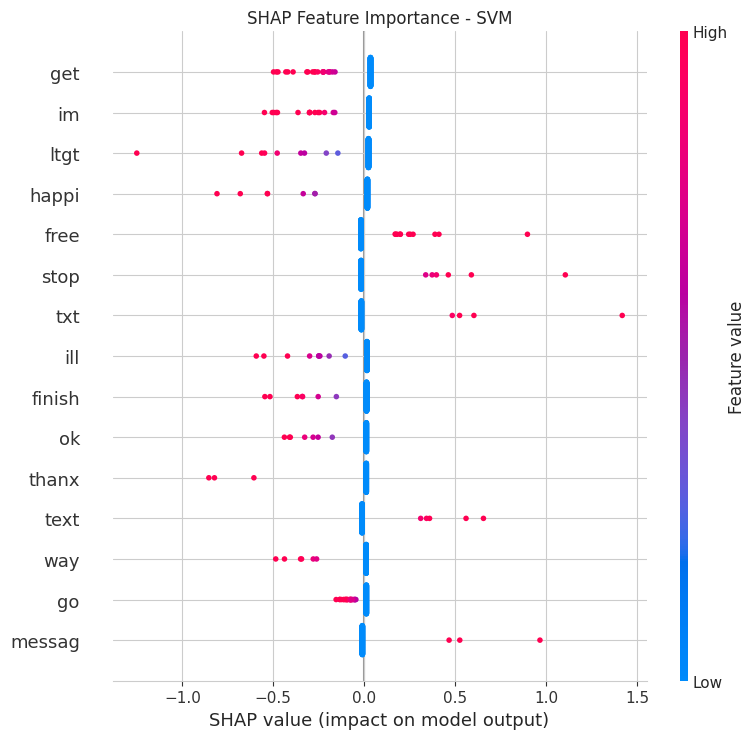

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_sample_plot, feature_names=feature_names, show=False, max_display=15)
plt.title(f'SHAP Feature Importance - {best_name}')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
if hasattr(mean_abs_shap, 'A1'):
    mean_abs_shap = mean_abs_shap.A1
top_idx = np.argsort(mean_abs_shap)[::-1][:15]
top_words = pd.DataFrame({'kata': feature_names[top_idx], 'mean_abs_shap': mean_abs_shap[top_idx]})
top_words

,kata,mean_abs_shap
0,get,0.062182
1,im,0.050962
2,ltgt,0.045439
3,happi,0.034316
4,free,0.033875
5,stop,0.032675
6,txt,0.030319
7,ill,0.029065
8,finish,0.025168
9,ok,0.022923


## 3. Interpretasi Hasil

Kata-kata dengan nilai `mean(|SHAP value|)` tertinggi merupakan fitur yang paling konsisten mempengaruhi
keputusan model — baik mendorong prediksi ke arah spam maupun ham:

- **'free', 'stop', 'txt', 'text'** — nilai fitur tinggi mendorong prediksi ke arah **spam**, konsisten
  dengan pola pesan promosi/penipuan yang menawarkan sesuatu gratis atau meminta balasan STOP/reply.
- **'im', 'ill', 'ok', 'happi', 'get'** — lebih banyak muncul pada konteks percakapan personal, mendorong
  prediksi ke arah **ham**.

Hasil ini selaras dengan temuan pada tahap EDA (notebook 01) di mana kata seperti *free*, *txt*, *call*, dan
*claim* memang menjadi penciri kuat pesan spam berdasarkan analisis frekuensi kata.

## 4. Perbandingan Singkat dengan Model Lain (Opsional)

Sebagai pembanding, berikut interpretasi SHAP juga dihitung untuk model **XGBoost** (tree-based) untuk
melihat apakah fitur penting yang teridentifikasi konsisten antar jenis model yang berbeda.

In [6]:
xgb_model = all_models.get('XGBoost')
if xgb_model is not None:
    shap_values_xgb, X_sample_xgb = compute_shap(xgb_model, 'XGBoost', X_sample)
    mean_abs_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)
    top_idx_xgb = np.argsort(mean_abs_shap_xgb)[::-1][:10]
    top_words_xgb = pd.DataFrame({'kata': feature_names[top_idx_xgb], 'mean_abs_shap': mean_abs_shap_xgb[top_idx_xgb]})
    print('Top 10 kata terpenting menurut XGBoost:')
    print(top_words_xgb)

    common_words = set(top_words['kata'].head(10)) & set(top_words_xgb['kata'])
    print(f"\nKata yang konsisten penting di kedua model (SVM & XGBoost): {common_words}")
else:
    print('Model XGBoost tidak ditemukan pada all_models.pkl')

Top 10 kata terpenting menurut XGBoost:
    kata  mean_abs_shap
0   call       0.813463
1    txt       0.352079
2   text       0.328519
3   free       0.289308
4     im       0.203811
5  repli       0.200207
6     go       0.169115
7   send       0.151009
8  claim       0.140428
9   ltgt       0.116470

Kata yang konsisten penting di kedua model (SVM & XGBoost): {'ltgt', 'free', 'im', 'txt'}


**Catatan:** Kesesuaian sebagian kata penting antar model (SVM vs XGBoost) memperkuat validitas temuan
bahwa kata-kata tersebut memang secara substansial membedakan pesan spam dan ham, bukan sekadar artefak dari
satu algoritma tertentu.

## 5. Simpan Hasil Interpretasi

In [7]:
top_words.to_csv('../reports/shap_top_words.csv', index=False)
print('Hasil interpretasi SHAP berhasil disimpan ke reports/shap_top_words.csv')

Hasil interpretasi SHAP berhasil disimpan ke reports/shap_top_words.csv


## 6. Kesimpulan Interpretasi

- Interpretasi SHAP terhadap model SVM (model terbaik) berhasil mengidentifikasi kata-kata paling
  berpengaruh terhadap prediksi spam/ham.
- Kata seperti **'free', 'stop', 'txt'** menjadi pendorong kuat prediksi spam, sedangkan kata-kata personal
  seperti **'im', 'ok', 'happi'** mendorong prediksi ham.
- Temuan ini konsisten dengan analisis frekuensi kata pada tahap EDA maupun pola serupa yang muncul pada
  model pembanding (XGBoost), memperkuat validitas insight yang dihasilkan.
- Insight ini menjadi dasar penjelasan pada halaman **"Interpretasi Hasil"** aplikasi Streamlit (Soal 4).
